   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns used for clustering:
Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male'], dtype='str')

--- WITHOUT SCALING ---
Cluster counts:
 0    89
3    38
4    33
2    29
1    11
Name: count, dtype: int64
Silhouette Score: 0.3574050351346702

--- WITH SCALING (except Age) ---
Cluster counts:
 1    58
3    41
2    40
4    33
0    28
Name: count, dtype: int64
Silhouette Score: 0.4993956844223334


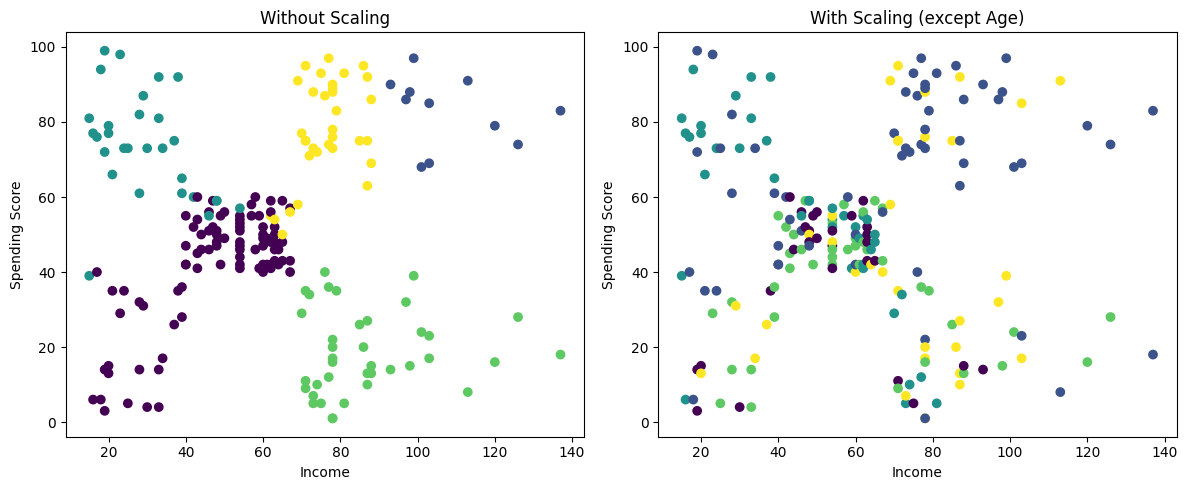

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

dataframe = pd.read_csv('Mall_Customers.csv')
print(dataframe.head())

features = dataframe.drop(columns=['CustomerID'])
features = pd.get_dummies(features, drop_first=True)
print("\nColumns used for clustering:")
print(features.columns)

kmeans_raw = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels_raw = kmeans_raw.fit_predict(features)
silhouette_raw = silhouette_score(features, labels_raw)

print("\n--- WITHOUT SCALING ---")
print("Cluster counts:\n", pd.Series(labels_raw).value_counts())
print("Silhouette Score:", silhouette_raw)


age_feature = features[['Age']]
remaining_features = features.drop(columns=['Age'])

scaler_model = StandardScaler()
scaled_remaining = scaler_model.fit_transform(remaining_features)

combined_scaled_features = np.concatenate([age_feature.values, scaled_remaining], axis=1)

kmeans_scaled_model = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels_scaled = kmeans_scaled_model.fit_predict(combined_scaled_features)

silhouette_scaled = silhouette_score(combined_scaled_features, labels_scaled)

print("\n--- WITH SCALING (except Age) ---")
print("Cluster counts:\n", pd.Series(labels_scaled).value_counts())
print("Silhouette Score:", silhouette_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(dataframe['Annual Income (k$)'], dataframe['Spending Score (1-100)'],
            c=labels_raw, cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Income')
plt.ylabel('Spending Score')

plt.subplot(1, 2, 2)
plt.scatter(dataframe['Annual Income (k$)'], dataframe['Spending Score (1-100)'],
            c=labels_scaled, cmap='viridis')
plt.title('With Scaling (except Age)')
plt.xlabel('Income')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)

   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   ---------------------------------------- 0/6 [pillow]
   -----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset:
    serial_id  miles_driven  fuel_avg  service_cost       type
0          5        150000        15          5000        SUV
1          3        120000        18          4000      Sedan
2          8        250000        10          7000      Truck
3          2         80000        22          2000  Hatchback
4          4        100000        20          3000      Sedan
5          7        220000        12          6500      Truck
6          6        180000        16          5500        SUV
7         10        300000         8          8000      Truck
8          1         75000        24          1500  Hatchback
9          9        280000         9          7500        SUV

Processed Features:
    miles_driven  fuel_avg  service_cost  type_Hatchback  type_SUV  type_Sedan  \
0        150000        15          5000           False      True       False   
1        120000        18          4000           False     False        True   
2        250000        10          7000    

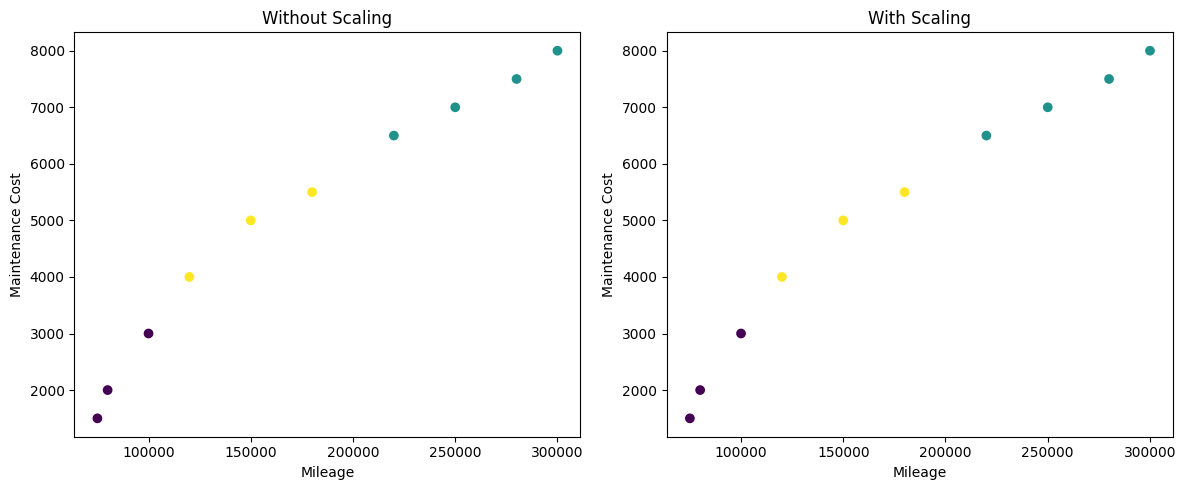

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

vehicle_data = {
    'serial_id': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'miles_driven': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_avg': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'service_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

dataset = pd.DataFrame(vehicle_data)
print("Dataset:\n", dataset)

feature_set = dataset.drop(columns=['serial_id'])
feature_set = pd.get_dummies(feature_set, columns=['type'])
print("\nProcessed Features:\n", feature_set.head())

kmeans_model_raw = KMeans(n_clusters=3, random_state=42)
labels_raw = kmeans_model_raw.fit_predict(feature_set)
silhouette_raw = silhouette_score(feature_set, labels_raw)

print("\n--- WITHOUT SCALING ---")
print("Cluster Labels:", labels_raw)
print("Cluster Counts:\n", pd.Series(labels_raw).value_counts())
print("Silhouette Score:", silhouette_raw)


categorical_columns = [col for col in feature_set.columns if 'type' in col]
numerical_columns = [col for col in feature_set.columns if col not in categorical_columns]

scaler_model = StandardScaler()
scaled_numeric = scaler_model.fit_transform(feature_set[numerical_columns])

final_scaled_features = np.concatenate([scaled_numeric, feature_set[categorical_columns].values], axis=1)

kmeans_model_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_model_scaled.fit_predict(final_scaled_features)
silhouette_scaled = silhouette_score(final_scaled_features, labels_scaled)

print("\n--- WITH SCALING ---")
print("Cluster Labels:", labels_scaled)
print("Cluster Counts:\n", pd.Series(labels_scaled).value_counts())
print("Silhouette Score:", silhouette_scaled)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(dataset['miles_driven'], dataset['service_cost'], c=labels_raw, cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Mileage')
plt.ylabel('Maintenance Cost')

plt.subplot(1, 2, 2)
plt.scatter(dataset['miles_driven'], dataset['service_cost'], c=labels_scaled, cmap='viridis')
plt.title('With Scaling')
plt.xlabel('Mileage')
plt.ylabel('Maintenance Cost')

plt.tight_layout()
plt.show()

Original Dataset:
     id  gpa_score  weekly_study  attendance_pct
0  101        3.5            15              90
1  102        2.8             8              75
2  103        3.9            20              95
3  104        2.5             5              60
4  105        3.2            12              85
5  106        3.7            18              92
6  107        2.2             4              55
7  108        3.0            10              80
8  109        3.8            19              93
9  110        2.7             7              70


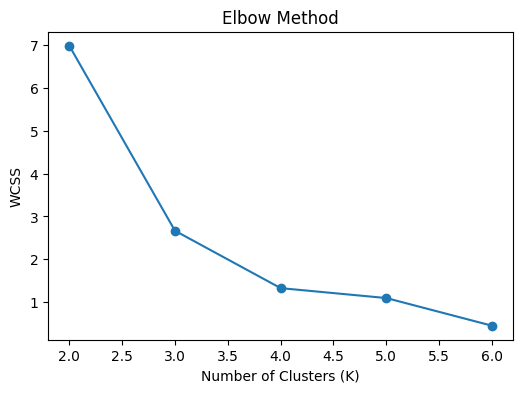


Final Dataset with Clusters:

    id  cluster_label
0  101              1
1  102              2
2  103              1
3  104              0
4  105              2
5  106              1
6  107              0
7  108              2
8  109              1
9  110              2


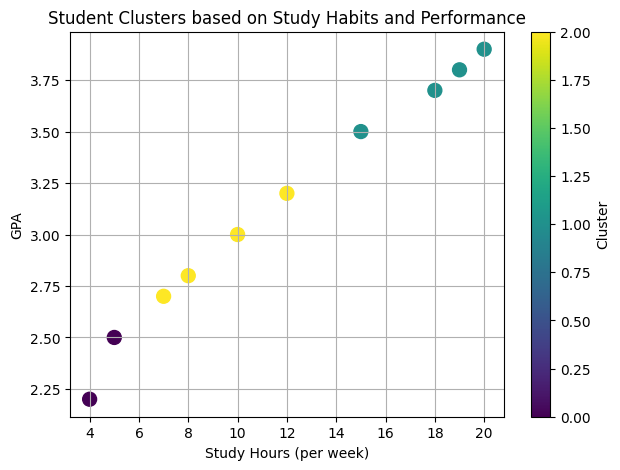

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

student_data = {
    'id': [101,102,103,104,105,106,107,108,109,110],
    'gpa_score': [3.5, 2.8, 3.9, 2.5, 3.2, 3.7, 2.2, 3.0, 3.8, 2.7],
    'weekly_study': [15, 8, 20, 5, 12, 18, 4, 10, 19, 7],
    'attendance_pct': [90, 75, 95, 60, 85, 92, 55, 80, 93, 70]
}

student_df = pd.DataFrame(student_data)
print("Original Dataset:\n", student_df)

features = student_df[['gpa_score', 'weekly_study', 'attendance_pct']]

scaler_model = StandardScaler()
scaled_features = scaler_model.fit_transform(features)

wcss_values = []
for k in range(2, 7):
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_model.fit(scaled_features)
    wcss_values.append(kmeans_model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,7), wcss_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

best_k = 3
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
student_df['cluster_label'] = final_kmeans.fit_predict(scaled_features)

print("\nFinal Dataset with Clusters:\n")
print(student_df[['id', 'cluster_label']])

plt.figure(figsize=(7,5))
plot = plt.scatter(student_df['weekly_study'], student_df['gpa_score'],
                   c=student_df['cluster_label'], cmap='viridis', s=100)

plt.title('Student Clusters based on Study Habits and Performance')
plt.xlabel('Study Hours (per week)')
plt.ylabel('GPA')
plt.colorbar(plot, label='Cluster')
plt.grid(True)
plt.show()